In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv("noisy_curvefit_data.csv")

#---2.1---
print(df.shape)
print(df.columns.tolist())
display(df.head())
display(df.tail())

(100, 6)
['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


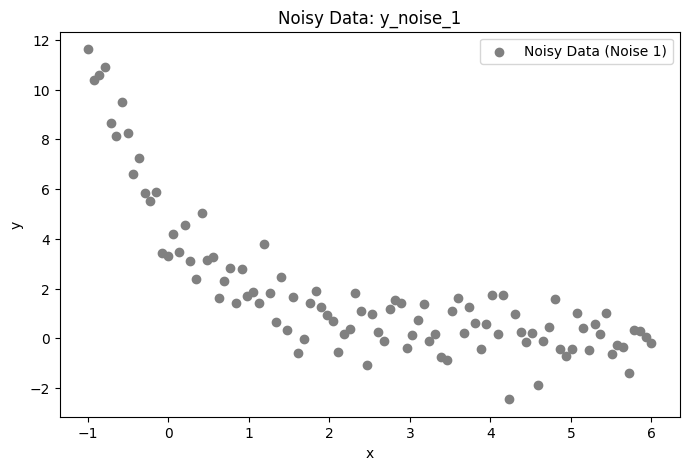

In [6]:
x = df["x"]
y_noise_1 = df["y_noise_1"]

plt.figure(figsize=(8,5))
plt.scatter(x, y_noise_1, color="gray", label="Noisy Data (Noise 1)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Data: y_noise_1")
plt.legend()
plt.show()

In [9]:
#---2.2---

def model(x,A,k):
    return A * np.exp(-k*x)

x = df['x'].values
y_noise_1 = df['y_noise_1'].values

p0 = [1,1]

popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt
print('A_fit=', A_fit)
print('k_fit=', k_fit)

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")


residuals = y_noise_1 - model(x, A_fit, k_fit)

chi2 = np.sum(residuals**2)

dof = len(x) - len(popt)

chi2_reduced = chi2 / dof




A_fit= 4.714813880431482
k_fit= 0.9183078508212074
Fit: y = 4.71 * e^(-0.92 * x)


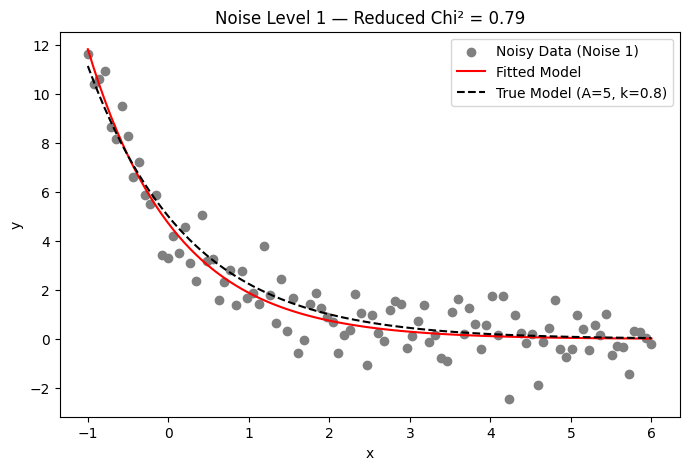

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(x, y_noise_1, color="gray", label="Noisy Data (Noise 1)")
plt.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted Model")
plt.plot(x, model(x, 5, 0.8), "k--", label="True Model (A=5, k=0.8)")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise Level 1 — Reduced Chi² = {chi2_reduced:.2f}")
plt.legend()
plt.show()


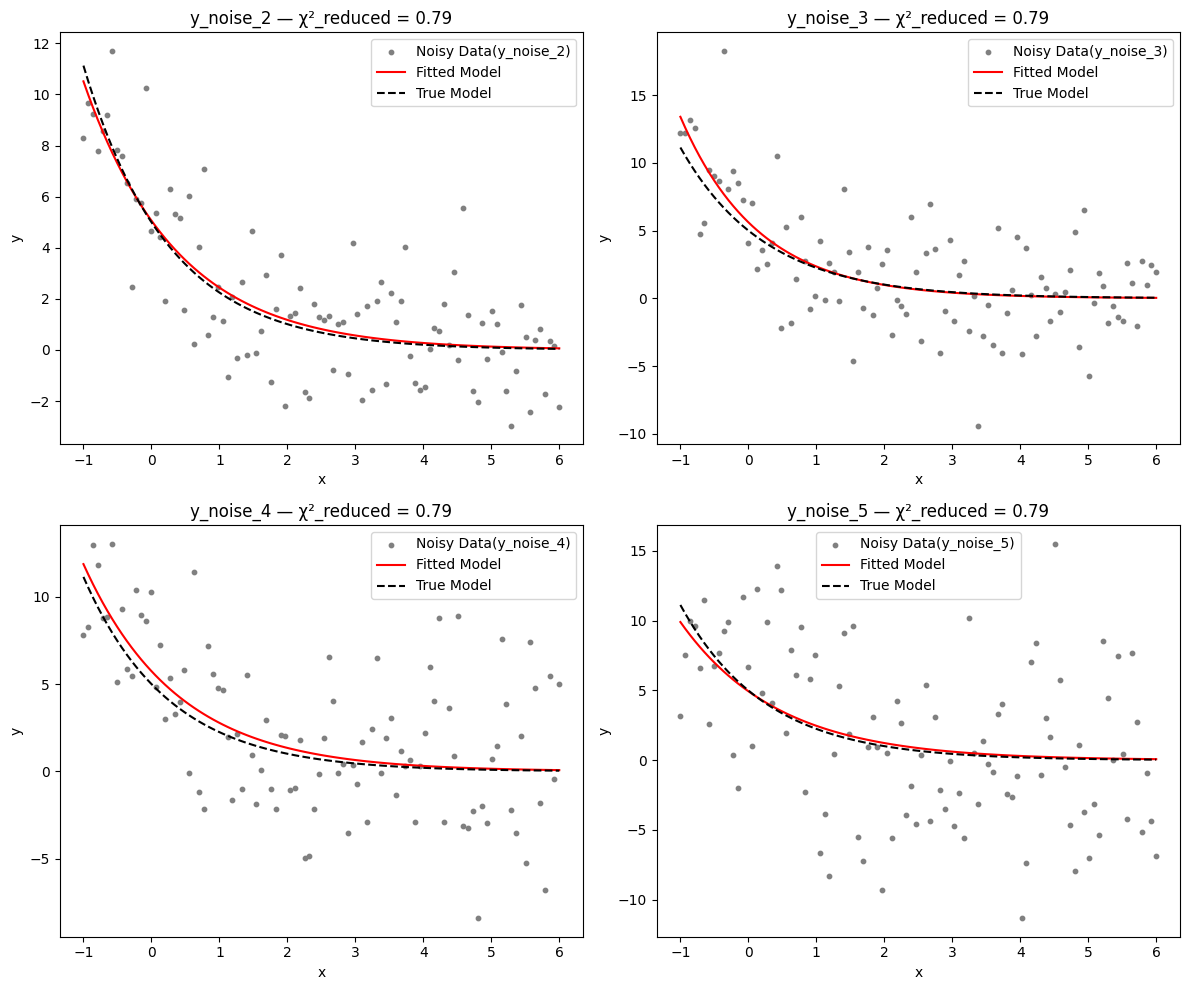

In [14]:
#---2.3---
def fit_model(x,y):
    p0 = [1,1]

    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    reduced_chi2 = chi2/dof

    return A_fit, k_fit, reduced_chi2

noise_columns = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for i, col in enumerate(noise_columns):

    y = df[col].values
    A_fit, k_fit, reduced_chi2 = fit_model(x,y)

    ax = axes[i]

    ax.scatter(x, y, color = "gray", s = 10, label = f"Noisy Data({col})")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted Model")
    ax.plot(x, model(x, 5, 0.8), "k--", label = "True Model")
    ax.set_title(f"{col} — χ²_reduced = {chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.legend()

plt.tight_layout()
plt.show()


In [17]:
#---2.4---
all_noise_cols = ["y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

results = {
    "Noise level": [],
    "A_fit": [],
    "k_fit": [],
    "Reduced chi-squared": []
}

for i, col in enumerate(all_noise_cols, start=1):
    y = df[col].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)

    results["Noise level"].append(i)
    results["A_fit"].append(A_fit)
    results["k_fit"].append(k_fit)
    results["Reduced chi-squared"].append(chi2_reduced)

df_results = pd.DataFrame(results)

df_results.to_csv("noisy_parameters.csv", index=False)




In [19]:
#checking
import os
os.listdir()

['homework9.ipynb',
 'noisy_parameters.csv',
 'noisy_curvefit_data.csv',
 'solar_system.csv',
 '.ipynb_checkpoints']